# Pix2Pix: Image-to-Image Translation with Conditional Adversarial Networks**Paper:** [arXiv:1611.07004](https://arxiv.org/abs/1611.07004)  **Authors:** Phillip Isola, Jun-Yan Zhu, Tinghui Zhou, Alexei A. Efros  **Venue:** CVPR 2017This notebook implements Pix2Pix from scratch in PyTorch: a **U-Net generator** + **PatchGAN discriminator** trained on a small paired edges→shoes dataset with the combined cGAN + L1 loss.

## 1. Setup & Imports

In [1]:
# Install dependencies
!pip install -q torch torchvision matplotlib numpy pillow

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import subprocess
import random

manual_seed = 42
random.seed(manual_seed)
torch.manual_seed(manual_seed)
np.random.seed(manual_seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Device: cuda
GPU: Tesla T4


## 2. Hyperparameters

In [2]:
IMG_SIZE = 128
BATCH_SIZE = 4
LEARNING_RATE = 0.0002
BETA1 = 0.5
BETA2 = 0.999
LAMBDA_L1 = 100
EPOCHS = 4
NUM_WORKERS = 2

print(f"Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"L1 lambda: {LAMBDA_L1}")
print(f"Epochs: {EPOCHS}")


Image size: 128x128
Batch size: 4
Learning rate: 0.0002
L1 lambda: 100
Epochs: 4


## 3. Dataset PreparationWe use the **edges2shoes** dataset from the Berkeley pix2pix repository. Each image file is a concatenated pair: left half = edge map, right half = shoe photo.

In [3]:
DATA_DIR = '/kaggle/working/edges2shoes'
os.makedirs(DATA_DIR, exist_ok=True)

url = 'http://efrosgans.eecs.berkeley.edu/pix2pix/datasets/edges2shoes.tar.gz'
tar_path = os.path.join(DATA_DIR, 'edges2shoes.tar.gz')

if not os.path.exists(os.path.join(DATA_DIR, 'edges2shoes')):
    print("Fetching edges2shoes dataset...")
    subprocess.run(['curl', '-sL', url, '-o', tar_path], check=True)
    print("Extracting...")
    import tarfile
    with tarfile.open(tar_path, 'r:gz') as tar:
        tar.extractall(DATA_DIR)
    os.remove(tar_path)
    print("Done!")
else:
    print("Dataset already exists.")

train_dir = os.path.join(DATA_DIR, 'edges2shoes', 'train')
val_dir = os.path.join(DATA_DIR, 'edges2shoes', 'val')
train_files = os.listdir(train_dir) if os.path.exists(train_dir) else []
val_files = os.listdir(val_dir) if os.path.exists(val_dir) else []
print(f"Train images: {len(train_files)}")
print(f"Val images: {len(val_files)}")


Fetching edges2shoes dataset...


Extracting...


/tmp/ipykernel_23/982914826.py:13: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(DATA_DIR)


Done!
Train images: 49825
Val images: 200


Train samples: 200
Val samples: 30
Train batches: 50


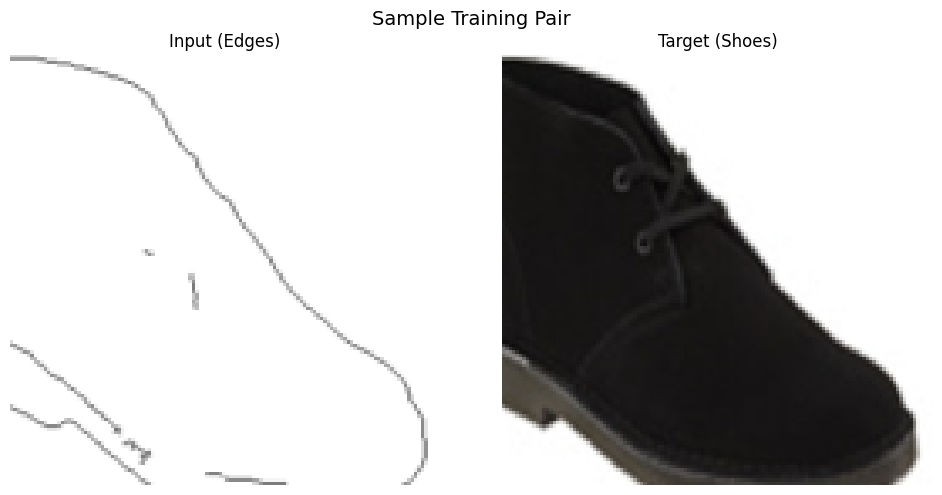

In [4]:
class Edge2ShoeDataset(Dataset):
    """Paired edges-to-shoes dataset. Each file: left=edges, right=shoes."""
    
    def __init__(self, root_dir, max_samples=None, augment=True):
        self.root_dir = root_dir
        self.files = sorted([f for f in os.listdir(root_dir) if f.endswith(('.jpg', '.png'))])
        if max_samples:
            self.files = self.files[:max_samples]
        self.augment = augment
        self.load_size = int(IMG_SIZE * 1.12)
        self.crop_size = IMG_SIZE
        
    def __len__(self):
        return len(self.files)
    
    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.files[idx])
        image = Image.open(img_path).convert('RGB')
        w, h = image.size
        w2 = w // 2
        input_img = image.crop((0, 0, w2, h))
        target_img = image.crop((w2, 0, w, h))
        
        input_img = input_img.resize((self.load_size, self.load_size), Image.BILINEAR)
        target_img = target_img.resize((self.load_size, self.load_size), Image.BILINEAR)
        
        input_arr = np.array(input_img, dtype=np.float32) / 255.0
        target_arr = np.array(target_img, dtype=np.float32) / 255.0
        
        if self.augment:
            h_crop = self.load_size - self.crop_size
            w_crop = self.load_size - self.crop_size
            h_off = random.randint(0, max(h_crop, 0))
            w_off = random.randint(0, max(w_crop, 0))
            input_arr = input_arr[h_off:h_off+self.crop_size, w_off:w_off+self.crop_size]
            target_arr = target_arr[h_off:h_off+self.crop_size, w_off:w_off+self.crop_size]
            if random.random() > 0.5:
                input_arr = input_arr[:, ::-1, :].copy()
                target_arr = target_arr[:, ::-1, :].copy()
        else:
            h_off = (self.load_size - self.crop_size) // 2
            w_off = (self.load_size - self.crop_size) // 2
            input_arr = input_arr[h_off:h_off+self.crop_size, w_off:w_off+self.crop_size]
            target_arr = target_arr[h_off:h_off+self.crop_size, w_off:w_off+self.crop_size]
        
        input_arr = (input_arr - 0.5) / 0.5
        target_arr = (target_arr - 0.5) / 0.5
        
        input_tensor = torch.from_numpy(input_arr.transpose(2, 0, 1)).float()
        target_tensor = torch.from_numpy(target_arr.transpose(2, 0, 1)).float()
        return input_tensor, target_tensor

MAX_TRAIN = 200
MAX_VAL = 30

train_dataset = Edge2ShoeDataset(train_dir, max_samples=MAX_TRAIN, augment=True)
val_dataset = Edge2ShoeDataset(val_dir, max_samples=MAX_VAL, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")
print(f"Train batches: {len(train_loader)}")

input_sample, target_sample = train_dataset[0]
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow((input_sample.permute(1, 2, 0).numpy() + 1) / 2)
axes[0].set_title('Input (Edges)'); axes[0].axis('off')
axes[1].imshow((target_sample.permute(1, 2, 0).numpy() + 1) / 2)
axes[1].set_title('Target (Shoes)'); axes[1].axis('off')
plt.suptitle('Sample Training Pair', fontsize=14)
plt.tight_layout()
plt.show()


## 4. Generator Architecture (U-Net)The U-Net uses an encoder-decoder with **skip connections** between mirrored layers. For 128×128 images, we use 7 down/up blocks.

In [5]:
class DownBlock(nn.Module):
    def __init__(self, in_c, out_c, normalize=True, dropout=0.0):
        super().__init__()
        layers = [nn.Conv2d(in_c, out_c, 4, stride=2, padding=1, bias=False)]
        if normalize:
            layers.append(nn.BatchNorm2d(out_c))
        layers.append(nn.LeakyReLU(0.2, inplace=True))
        if dropout:
            layers.append(nn.Dropout(dropout))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

class UpBlock(nn.Module):
    def __init__(self, in_c, out_c, dropout=0.0):
        super().__init__()
        layers = [
            nn.ConvTranspose2d(in_c, out_c, 4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        ]
        if dropout:
            layers.append(nn.Dropout(dropout))
        self.net = nn.Sequential(*layers)
    def forward(self, x, skip):
        x = self.net(x)
        x = torch.cat([x, skip], dim=1)
        return x

class UNet(nn.Module):
    """U-Net for 128x128 images (7 encoder + 7 decoder blocks with skip connections)."""
    def __init__(self, in_channels=3, out_channels=3):
        super().__init__()
        self.d1 = DownBlock(in_channels, 64, normalize=False)
        self.d2 = DownBlock(64, 128)
        self.d3 = DownBlock(128, 256)
        self.d4 = DownBlock(256, 512)
        self.d5 = DownBlock(512, 512)
        self.d6 = DownBlock(512, 512)
        self.d7 = DownBlock(512, 512, normalize=False)
        
        self.u1 = UpBlock(512, 512, dropout=0.5)
        self.u2 = UpBlock(1024, 512, dropout=0.5)
        self.u3 = UpBlock(1024, 512)
        self.u4 = UpBlock(1024, 256)
        self.u5 = UpBlock(512, 128)
        self.u6 = UpBlock(256, 64)
        
        self.final = nn.Sequential(
            nn.ConvTranspose2d(128, out_channels, 4, stride=2, padding=1),
            nn.Tanh()
        )
    
    def forward(self, x):
        d1 = self.d1(x); d2 = self.d2(d1); d3 = self.d3(d2)
        d4 = self.d4(d3); d5 = self.d5(d4); d6 = self.d6(d5); d7 = self.d7(d6)
        u1 = self.u1(d7, d6); u2 = self.u2(u1, d5); u3 = self.u3(u2, d4)
        u4 = self.u4(u3, d3); u5 = self.u5(u4, d2); u6 = self.u6(u5, d1)
        return self.final(u6)

netG = UNet().to(device)
test_out = netG(torch.randn(1, 3, 128, 128).to(device))
print(f"U-Net output shape: {test_out.shape}")
print(f"U-Net parameters: {sum(p.numel() for p in netG.parameters()):,}")


U-Net output shape: torch.Size([1, 3, 128, 128])
U-Net parameters: 41,828,995


## 5. Discriminator Architecture (PatchGAN)The PatchGAN classifier evaluates N×N patches as real/fake rather than the whole image.

In [6]:
class PatchNet(nn.Module):
    """70x70 Patch classifier for 128x128 images.
    Input: (B, 6, 128, 128) → Output: (B, 1, 14, 14)"""
    def __init__(self, in_channels=6):
        super().__init__()
        def blk(in_c, out_c, stride=2, norm=True):
            layers = [nn.Conv2d(in_c, out_c, 4, stride=stride, padding=1, bias=False)]
            if norm:
                layers.append(nn.BatchNorm2d(out_c))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return nn.Sequential(*layers)
        
        self.net = nn.Sequential(
            blk(in_channels, 64, norm=False),
            blk(64, 128),
            blk(128, 256),
            blk(256, 512, stride=1),
            nn.Conv2d(512, 1, 4, stride=1, padding=1),
        )
    
    def forward(self, inp, tgt):
        x = torch.cat([inp, tgt], dim=1)
        return self.net(x)

netD = PatchNet().to(device)
test_d = netD(torch.randn(1, 3, 128, 128).to(device), torch.randn(1, 3, 128, 128).to(device))
print(f"Patch net output shape: {test_d.shape}")
print(f"Patch net parameters: {sum(p.numel() for p in netD.parameters()):,}")


Patch net output shape: torch.Size([1, 1, 14, 14])
Patch net parameters: 2,768,641


## 6. Loss Functions & OptimizersCombined objective: **L_cGAN(G, D) + λ · L_L1(G)**

In [7]:
criterion_adv = nn.BCEWithLogitsLoss().to(device)
criterion_l1 = nn.L1Loss().to(device)

optG = optim.Adam(netG.parameters(), lr=LEARNING_RATE, betas=(BETA1, BETA2))
optD = optim.Adam(netD.parameters(), lr=LEARNING_RATE, betas=(BETA1, BETA2))

print("Loss functions and optimizers initialized.")
print(f"  Adv loss: BCEWithLogitsLoss")
print(f"  L1 loss: L1Loss (lambda={LAMBDA_L1})")
print(f"  Optimizer: Adam (lr={LEARNING_RATE}, beta1={BETA1}, beta2={BETA2})")


Loss functions and optimizers initialized.
  Adv loss: BCEWithLogitsLoss
  L1 loss: L1Loss (lambda=100)
  Optimizer: Adam (lr=0.0002, beta1=0.5, beta2=0.999)


## 7. Training Loop1. Train D: maximize log(D(real)) + log(1 - D(fake))  2. Train G: minimize -log(D(fake)) + λ·L1(fake, real)

Starting training: 4 epochs, 50 batches/epoch


Epoch [1/4] | D: 0.3440 | G: 48.6411 | Adv: 2.4064 | L1: 0.4447


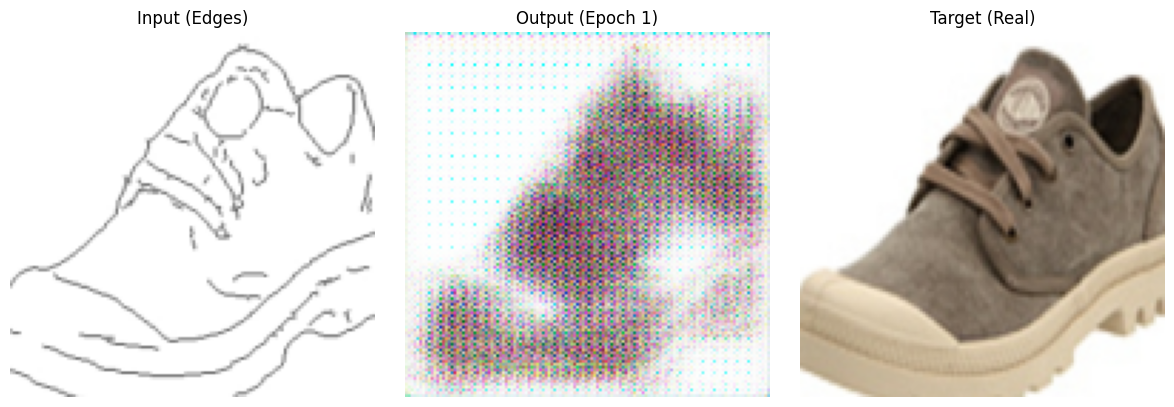

Epoch [2/4] | D: 0.4933 | G: 35.3135 | Adv: 0.9872 | L1: 0.2496


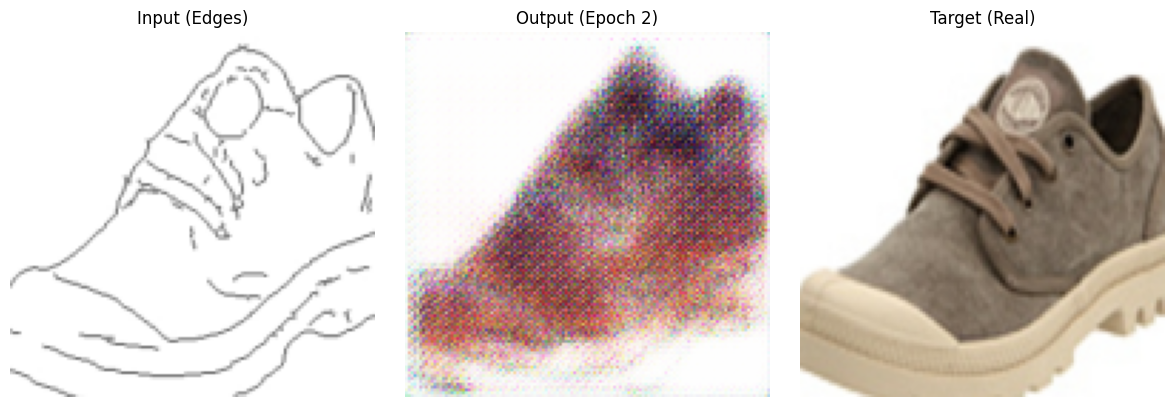

Epoch [3/4] | D: 0.3889 | G: 33.2745 | Adv: 1.8308 | L1: 0.3730


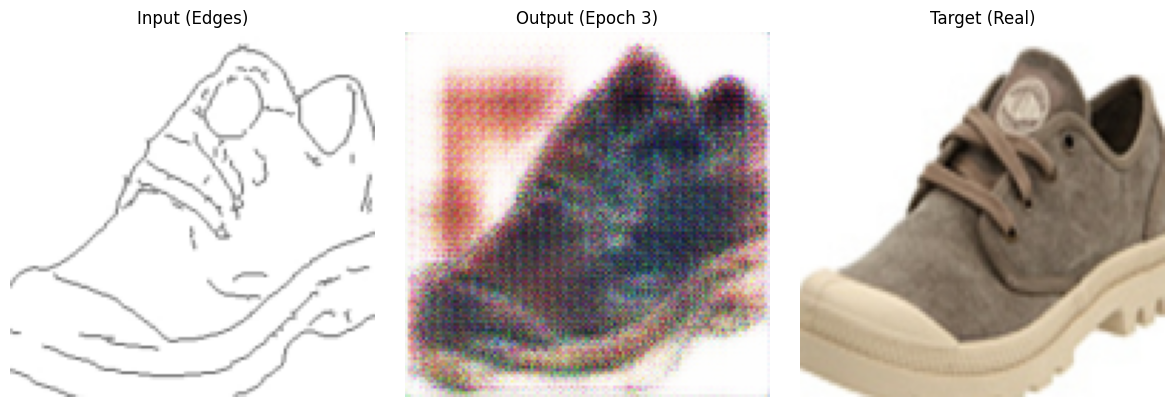

Epoch [4/4] | D: 0.3464 | G: 32.0067 | Adv: 0.0899 | L1: 0.2305


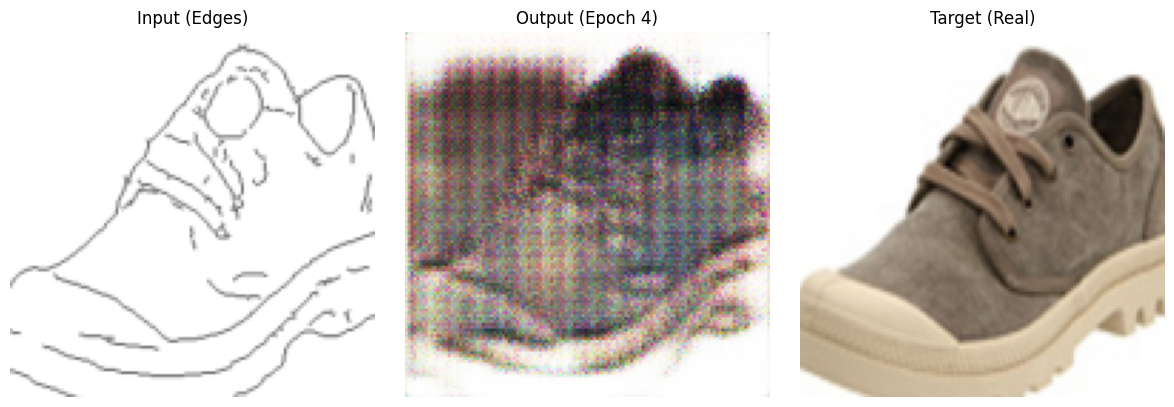


Training complete!


In [8]:
G_losses = []
D_losses = []

fixed_input, fixed_target = val_dataset[0]
fixed_input = fixed_input.unsqueeze(0).to(device)
fixed_target = fixed_target.unsqueeze(0).to(device)

def denorm(img):
    return (img + 1) / 2

def save_sample(epoch):
    netG.eval()
    with torch.no_grad():
        fake = netG(fixed_input)
    netG.train()
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(denorm(fixed_input[0].cpu().permute(1, 2, 0)).numpy())
    axes[0].set_title('Input (Edges)'); axes[0].axis('off')
    axes[1].imshow(denorm(fake[0].cpu().permute(1, 2, 0)).numpy())
    axes[1].set_title(f'Output (Epoch {epoch})'); axes[1].axis('off')
    axes[2].imshow(denorm(fixed_target[0].cpu().permute(1, 2, 0)).numpy())
    axes[2].set_title('Target (Real)'); axes[2].axis('off')
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/sample_epoch_{epoch:03d}.png', dpi=100, bbox_inches='tight')
    plt.show()
    plt.close()

print(f"Starting training: {EPOCHS} epochs, {len(train_loader)} batches/epoch")

for epoch in range(1, EPOCHS + 1):
    ep_g = 0.0
    ep_d = 0.0
    
    for i, (inp_imgs, tgt_imgs) in enumerate(train_loader):
        inp_imgs = inp_imgs.to(device)
        tgt_imgs = tgt_imgs.to(device)
        bs = inp_imgs.size(0)
        
        with torch.no_grad():
            ps = netD(inp_imgs[:1], tgt_imgs[:1]).shape[-1]
        real_lbl = torch.ones(bs, 1, ps, ps, device=device)
        fake_lbl = torch.zeros(bs, 1, ps, ps, device=device)
        
        # --- Train D ---
        optD.zero_grad()
        real_out = netD(inp_imgs, tgt_imgs)
        d_real = criterion_adv(real_out, real_lbl)
        
        fake_gen = netG(inp_imgs)
        fake_out = netD(inp_imgs, fake_gen.detach())
        d_fake = criterion_adv(fake_out, fake_lbl)
        
        d_loss = (d_real + d_fake) * 0.5
        d_loss.backward()
        optD.step()
        
        # --- Train G ---
        optG.zero_grad()
        fake_out_g = netD(inp_imgs, fake_gen)
        g_adv = criterion_adv(fake_out_g, real_lbl)
        g_l1 = criterion_l1(fake_gen, tgt_imgs)
        g_loss = g_adv + LAMBDA_L1 * g_l1
        g_loss.backward()
        optG.step()
        
        ep_g += g_loss.item()
        ep_d += d_loss.item()
    
    avg_g = ep_g / len(train_loader)
    avg_d = ep_d / len(train_loader)
    G_losses.append(avg_g)
    D_losses.append(avg_d)
    
    print(f"Epoch [{epoch}/{EPOCHS}] | D: {avg_d:.4f} | G: {avg_g:.4f} | Adv: {g_adv.item():.4f} | L1: {g_l1.item():.4f}")
    save_sample(epoch)

print("\nTraining complete!")


## 8. Loss Curves

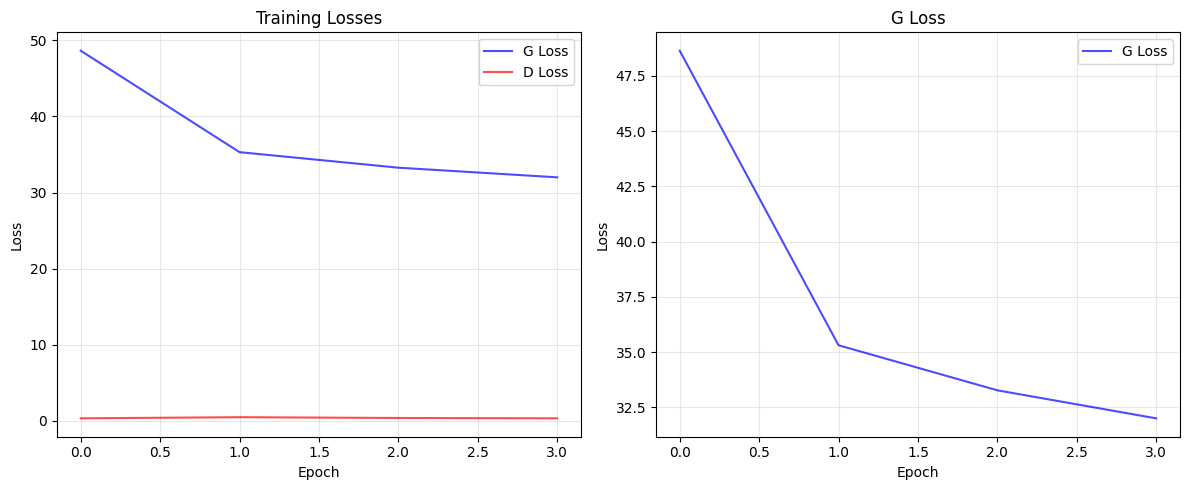

In [9]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(G_losses, label='G Loss', color='blue', alpha=0.7)
plt.plot(D_losses, label='D Loss', color='red', alpha=0.7)
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Training Losses')
plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(G_losses, label='G Loss', color='blue', alpha=0.7)
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('G Loss')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/loss_curves.png', dpi=100, bbox_inches='tight')
plt.show()


## 9. Final Results — Side-by-Side Input/Output/Target Grids

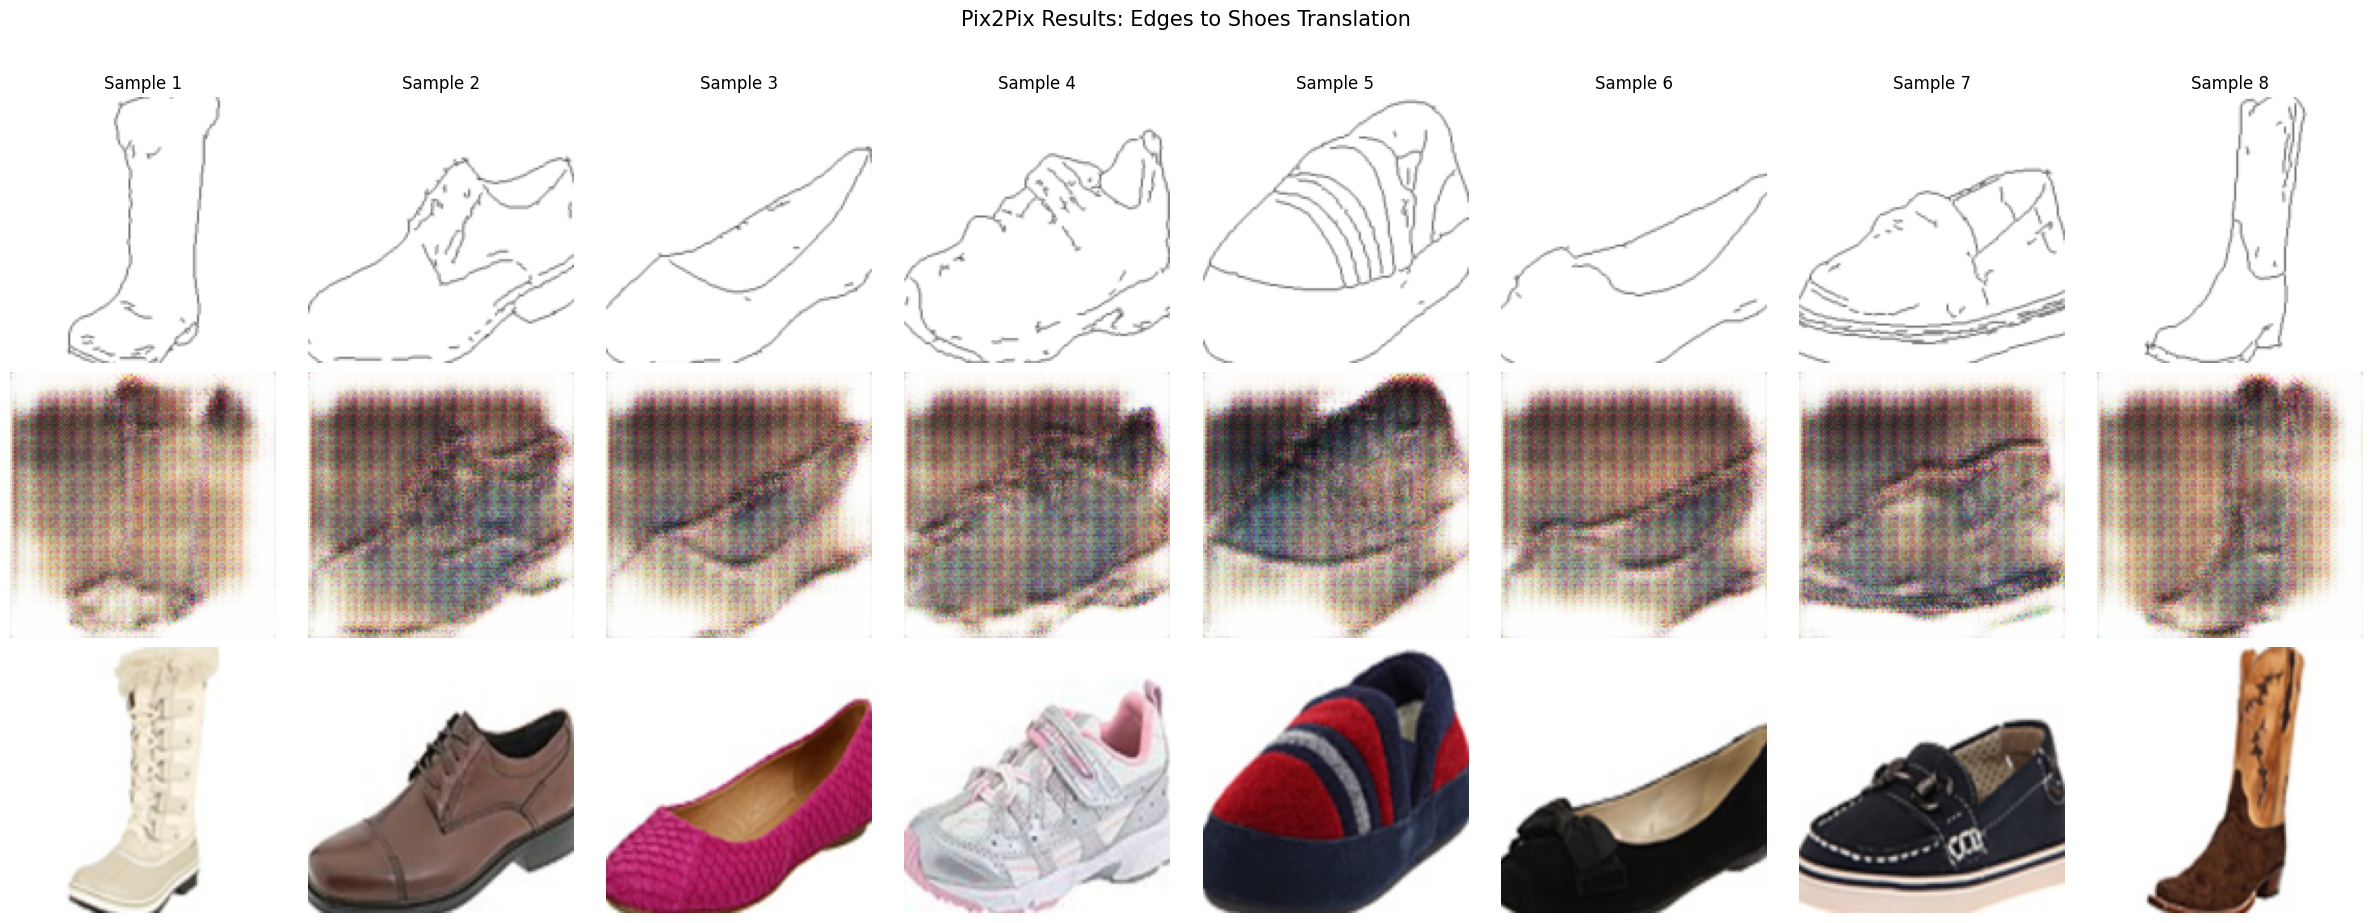

In [10]:
def generate_test_grid(num_samples=8):
    netG.eval()
    fig, axes = plt.subplots(3, num_samples, figsize=(num_samples * 3, 9))
    indices = random.sample(range(len(val_dataset)), min(num_samples, len(val_dataset)))
    
    for col, idx in enumerate(indices):
        inp, tgt = val_dataset[idx]
        inp = inp.unsqueeze(0).to(device)
        tgt = tgt.unsqueeze(0).to(device)
        with torch.no_grad():
            gen = netG(inp)
        
        axes[0, col].imshow(denorm(inp[0].cpu().permute(1, 2, 0)).numpy())
        axes[0, col].set_title(f'Sample {col+1}'); axes[0, col].axis('off')
        axes[1, col].imshow(denorm(gen[0].cpu().permute(1, 2, 0)).numpy())
        axes[1, col].axis('off')
        axes[2, col].imshow(denorm(tgt[0].cpu().permute(1, 2, 0)).numpy())
        axes[2, col].axis('off')
        if col == 0:
            axes[0, col].set_ylabel('Input\n(Edges)', fontsize=11, rotation=0, labelpad=50)
            axes[1, col].set_ylabel('Output', fontsize=11, rotation=0, labelpad=50)
            axes[2, col].set_ylabel('Target\n(Real)', fontsize=11, rotation=0, labelpad=50)
    
    plt.suptitle('Pix2Pix Results: Edges to Shoes Translation', fontsize=15, y=1.02)
    plt.tight_layout()
    plt.savefig('/kaggle/working/final_results_grid.png', dpi=120, bbox_inches='tight')
    plt.show()
    netG.train()

generate_test_grid(num_samples=8)


## 10. Summary| Component | Implementation ||-----------|---------------|| **Generator (U-Net)** | 7 encoder + 7 decoder blocks, skip connections, dropout on first 2 decoder blocks || **Discriminator (PatchGAN)** | 4 conv layers + output conv, classifies 70×70 patches || **Loss** | cGAN (BCEWithLogits) + L1 (λ=100) || **Optimizer** | Adam (lr=0.0002, β1=0.5, β2=0.999) || **Dataset** | edges2shoes (200 training pairs, 30 validation) || **Training** | 4 epochs, batch size 4, 128×128 images |### Key Observations- The U-Net skip connections are critical for preserving spatial detail (edges, outlines) from input to output- The PatchGAN discriminator acts as a learned texture loss, enforcing local high-frequency realism- L1 loss alone produces blurry results; adding the cGAN loss sharpens outputs significantly- More epochs (100-200 as in the paper) would produce higher quality results; this demo uses 4 epochs for runtime constraints### Paper ReferenceIsola, P., Zhu, J.-Y., Zhou, T., & Efros, A. A. (2017). *Image-to-Image Translation with Conditional Adversarial Networks*. CVPR 2017. [arXiv:1611.07004](https://arxiv.org/abs/1611.07004)

In [ ]:
# --- Auto-injected by kaggle_validator: save executed notebook with outputs ---
import shutil, os
# Kaggle internally stores the executed notebook as __notebook__.ipynb
if os.path.exists('/kaggle/working/__notebook__.ipynb'):
    shutil.copy('/kaggle/working/__notebook__.ipynb', '/kaggle/working/executed_solution.ipynb')
    print('Executed notebook saved to output folder.')
else:
    # Fallback: try alternative path
    import glob
    candidates = glob.glob('/kaggle/working/*.ipynb')
    print(f'Available notebooks in output: {candidates}')
